# Time Series Analysis in Python: A Complete Guide
## From Fundamentals to Forecasting

This notebook provides a comprehensive introduction to time series analysis using Python, covering theory, implementation, and practical applications.

## Part 1: Setup and Libraries

First, let's import all necessary libraries and configure visualization settings.

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
import warnings
warnings.filterwarnings('ignore')

# Time series specific
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 2: Understanding Time Series Data

### What is Time Series Data?

Time series data is a sequence of observations recorded at regular intervals over time. Key characteristics:
- **Temporal Order**: Order of observations matters
- **Dependence**: Values are often correlated with past values
- **Trend**: Long-term increase or decrease
- **Seasonality**: Regular patterns repeating at fixed intervals
- **Noise**: Random variations

### Components of Time Series:
$$Y_t = T_t + S_t + R_t$$
- **Trend (T_t)**: Long-term progression
- **Seasonality (S_t)**: Repeating patterns
- **Residual (R_t)**: Irregular component

## Part 3: Creating Sample Time Series Data

Let's create synthetic time series data to demonstrate concepts.

In [2]:
# Create a date range (2 years of daily data)
dates = pd.date_range(start='2022-01-01', end='2023-12-31', freq='D')

# Generate components
# Trend: linear increase
trend = np.linspace(100, 150, len(dates))

# Seasonality: annual cycle
seasonality = 20 * np.sin(2 * np.pi * np.arange(len(dates)) / 365)

# Noise: random variations
noise = np.random.normal(0, 5, len(dates))

# Combine components
data = trend + seasonality + noise

# Create DataFrame
ts_data = pd.DataFrame({
    'date': dates,
    'value': data,
    'trend': trend,
    'seasonality': seasonality
})

ts_data.set_index('date', inplace=True)

print("Data shape:", ts_data.shape)
print("\nFirst few rows:")
print(ts_data.head())
print("\nData statistics:")
print(ts_data.describe())

Data shape: (730, 3)

First few rows:
                 value       trend  seasonality
date                                           
2022-01-01  102.483571  100.000000     0.000000
2022-01-02   99.721533  100.068587     0.344267
2022-01-03  104.064049  100.137174     0.688432
2022-01-04  108.853304  100.205761     1.032393
2022-01-05  100.479630  100.274348     1.376049

Data statistics:
            value       trend   seasonality
count  730.000000  730.000000  7.300000e+02
mean   124.929831  125.000000  6.229416e-16
std     16.344467   14.463452  1.415183e+01
min     82.171211  100.000000 -1.999981e+01
25%    112.246927  112.500000 -1.411167e+01
50%    124.916186  125.000000  6.432491e-15
75%    137.476827  137.500000  1.411167e+01
max    166.793519  150.000000  1.999981e+01


## Part 4: Exploratory Data Analysis (EDA)

### Visualization

Always start by visualizing your time series data to understand patterns.

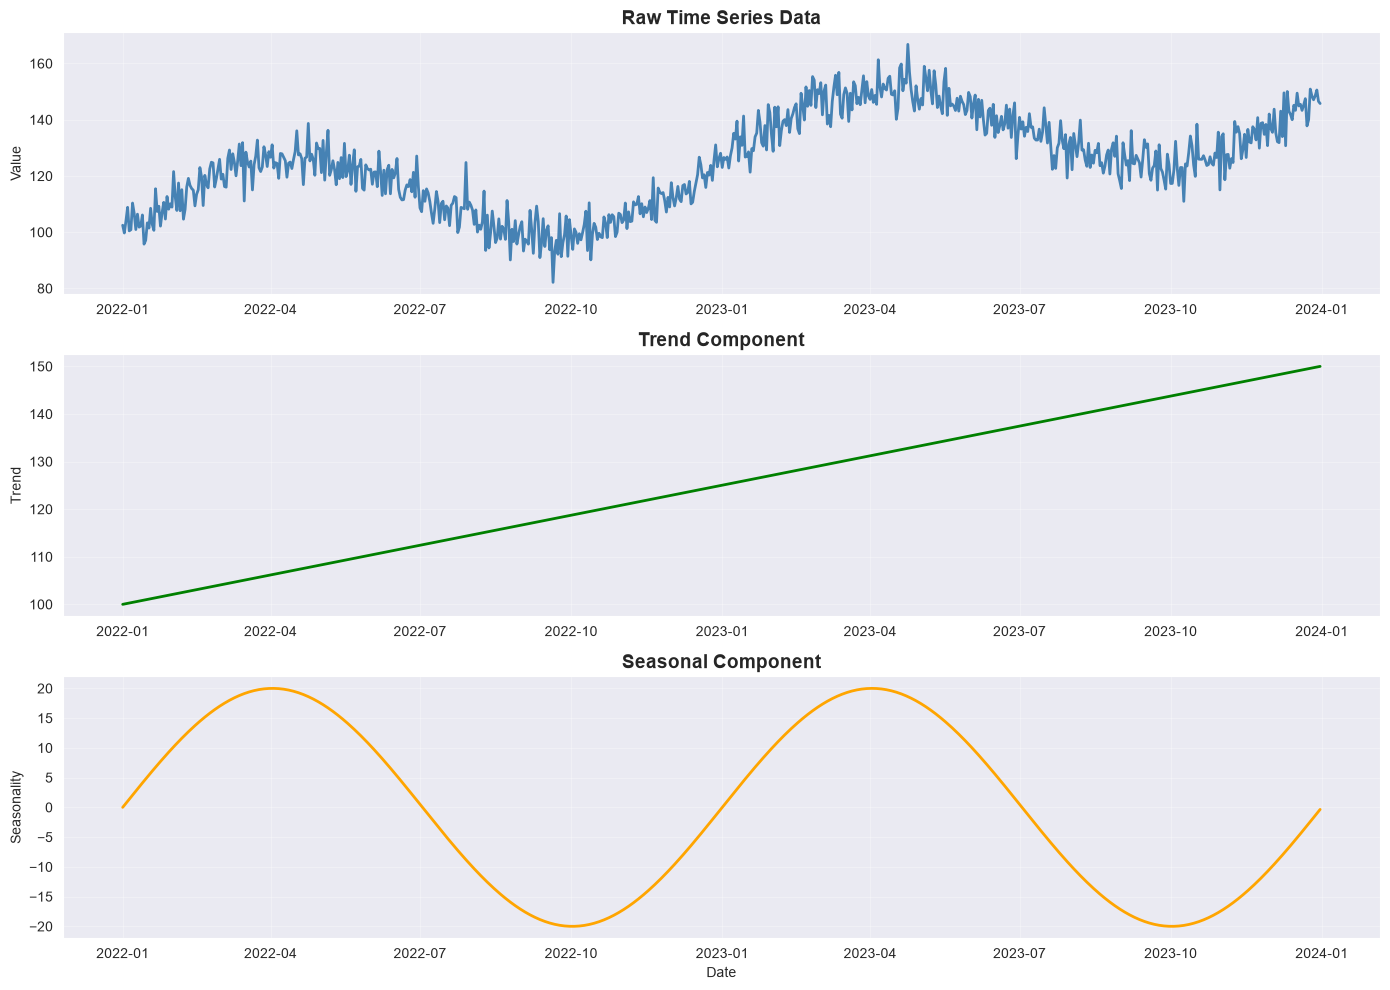

Time series components visualized successfully!


In [3]:
# Plot the complete time series
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Raw data
axes[0].plot(ts_data.index, ts_data['value'], linewidth=2, color='steelblue')
axes[0].set_title('Raw Time Series Data', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(ts_data.index, ts_data['trend'], linewidth=2, color='green')
axes[1].set_title('Trend Component', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Seasonality
axes[2].plot(ts_data.index, ts_data['seasonality'], linewidth=2, color='orange')
axes[2].set_title('Seasonal Component', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seasonality')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Time series components visualized successfully!")

## Part 5: Time Series Decomposition

Decompose the time series into its components (trend, seasonality, residuals) using statsmodels.

<Figure size 1400x1000 with 0 Axes>

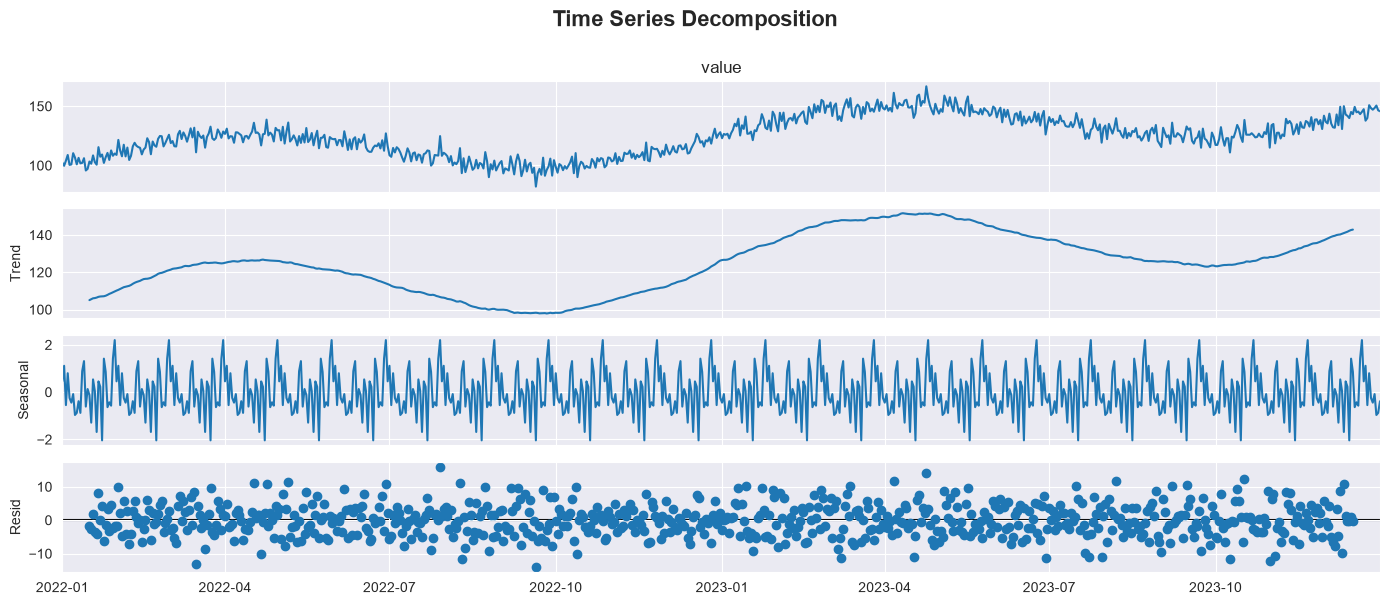

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Decompose
decomposition = seasonal_decompose(ts_data['value'], model='additive', period=30)

# Create figure with desired size
fig = plt.figure(figsize=(14, 10))
decomposition.plot()
plt.suptitle('Time Series Decomposition', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


In [5]:
# Perform seasonal decomposition
# 365 is the seasonal period (days in a year)
decomposition = seasonal_decompose(ts_data['value'], model='additive', period=365)

# Plot decomposition
fig = decomposition.plot(figsize=(14, 10))
plt.suptitle('Time Series Decomposition', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Extract components
print("\nDecomposition Components:")
print(f"Trend shape: {decomposition.trend.shape}")
print(f"Seasonal shape: {decomposition.seasonal.shape}")
print(f"Residual shape: {decomposition.resid.shape}")

TypeError: DecomposeResult.plot() got an unexpected keyword argument 'figsize'

## Part 6: Stationarity Testing

### Why Stationarity Matters?

Most time series models (ARIMA) require **stationary** data:
- **Constant mean**: Average value doesn't change over time
- **Constant variance**: Spread of values remains similar
- **No autocorrelation in residuals**: No patterns in errors

### Tests for Stationarity:

In [7]:
def perform_stationarity_tests(timeseries, name='Series'):
    """
    Perform ADF and KPSS tests for stationarity.
    
    ADF Test:
    - H0: Series has unit root (non-stationary)
    - H1: Series is stationary
    - Reject H0 if p-value < 0.05
    
    KPSS Test:
    - H0: Series is stationary
    - H1: Series has unit root (non-stationary)
    - Fail to reject H0 if p-value > 0.05
    """
    
    print(f"\n{'='*60}")
    print(f"Stationarity Tests for: {name}")
    print(f"{'='*60}")
    
    # ADF Test
    adf_result = adfuller(timeseries.dropna())
    print(f"\nAugmented Dickey-Fuller Test:")
    print(f"  Test Statistic: {adf_result[0]:.6f}")
    print(f"  P-value: {adf_result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.3f}")
    print(f"  Interpretation: {'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY'}")
    
    # KPSS Test
    kpss_result = kpss(timeseries.dropna(), regression='c')
    print(f"\nKPSS Test:")
    print(f"  Test Statistic: {kpss_result[0]:.6f}")
    print(f"  P-value: {kpss_result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"    {key}: {value:.3f}")
    print(f"  Interpretation: {'STATIONARY' if kpss_result[1] > 0.05 else 'NON-STATIONARY'}")
    
    return adf_result, kpss_result

# Test original series
adf_orig, kpss_orig = perform_stationarity_tests(ts_data['value'], 'Original Series')


Stationarity Tests for: Original Series

Augmented Dickey-Fuller Test:
  Test Statistic: -1.194634
  P-value: 0.675900
  Critical Values:
    1%: -3.440
    5%: -2.866
    10%: -2.569
  Interpretation: NON-STATIONARY

KPSS Test:
  Test Statistic: 1.732679
  P-value: 0.010000
  Critical Values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  Interpretation: NON-STATIONARY


C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_17436\3175072646.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_result = kpss(timeseries.dropna(), regression='c')


### Making Series Stationary

If a series is non-stationary, we can apply differencing.

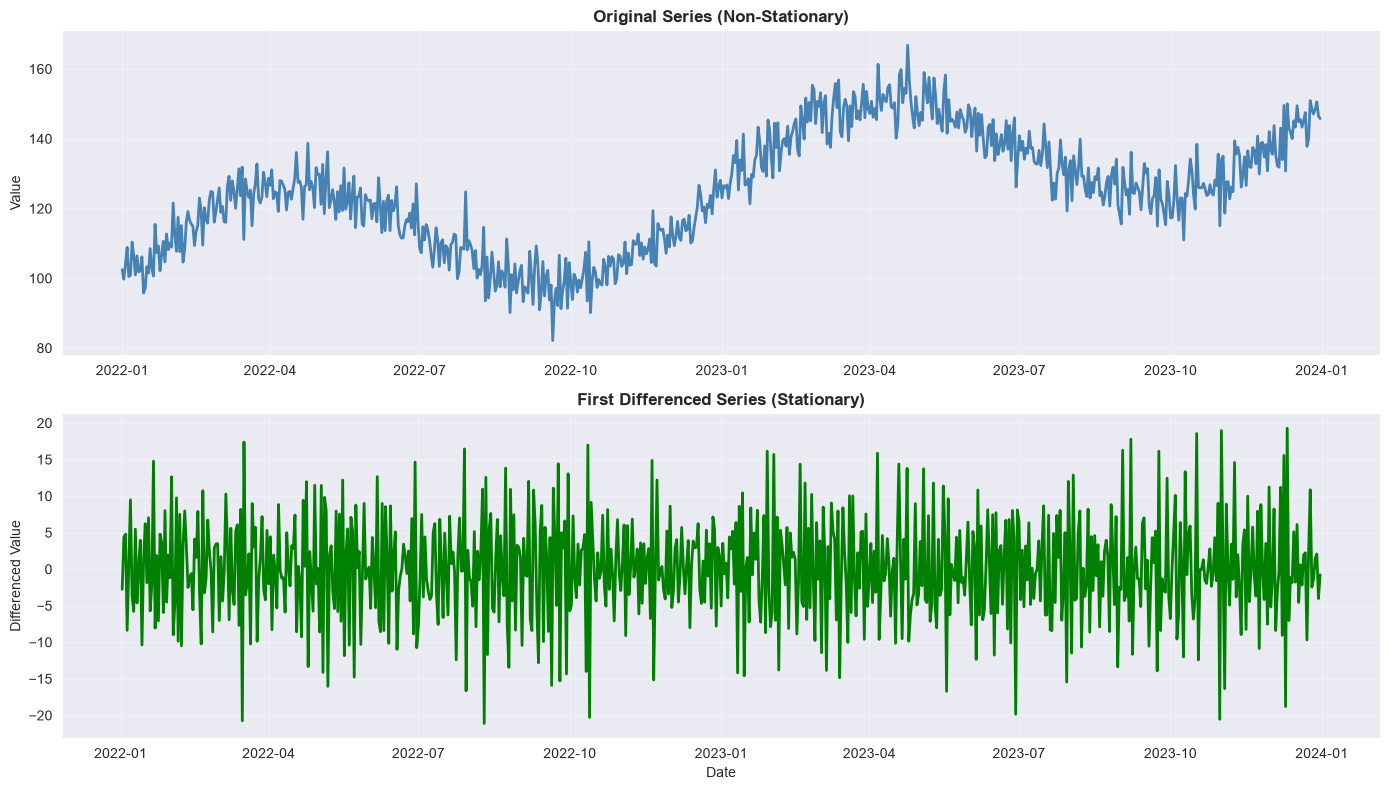


Stationarity Tests for: First Differenced Series

Augmented Dickey-Fuller Test:
  Test Statistic: -5.117752
  P-value: 0.000013
  Critical Values:
    1%: -3.440
    5%: -2.866
    10%: -2.569
  Interpretation: STATIONARY

KPSS Test:
  Test Statistic: 0.074269
  P-value: 0.100000
  Critical Values:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  Interpretation: STATIONARY


C:\Users\SHUBHAM\AppData\Local\Temp\ipykernel_17436\3175072646.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(timeseries.dropna(), regression='c')


In [8]:
# Apply differencing
diff_1 = ts_data['value'].diff().dropna()

# Plot original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(ts_data.index, ts_data['value'], linewidth=2, color='steelblue')
axes[0].set_title('Original Series (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

axes[1].plot(diff_1.index, diff_1, linewidth=2, color='green')
axes[1].set_title('First Differenced Series (Stationary)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Differenced Value')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test differenced series
adf_diff, kpss_diff = perform_stationarity_tests(diff_1, 'First Differenced Series')

## Part 7: ACF and PACF Analysis

### Autocorrelation (ACF) and Partial Autocorrelation (PACF)

These plots help identify the order of AR and MA terms:
- **ACF**: Correlation of series with its past values
- **PACF**: Correlation after removing intermediate values

Used to determine ARIMA parameters (p, d, q)

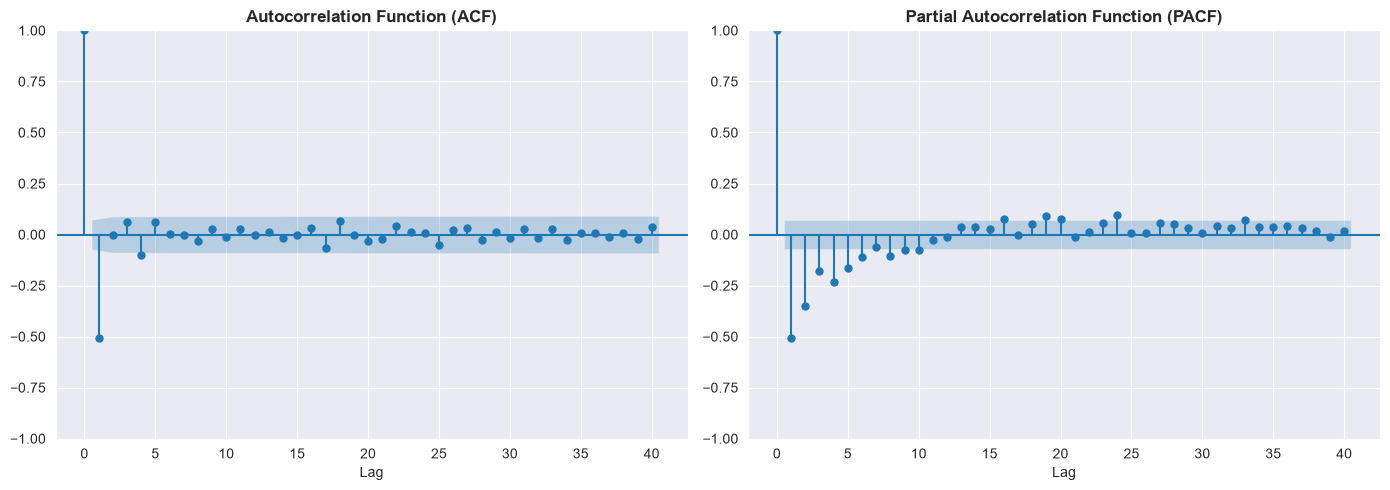


ACF/PACF Interpretation Guide:
- If ACF tails off and PACF cuts off at lag p → AR(p) model
- If PACF tails off and ACF cuts off at lag q → MA(q) model
- If both tail off → ARMA(p,q) model


In [9]:
# Plot ACF and PACF for differenced series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot
plot_acf(diff_1, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')

# PACF plot
plot_pacf(diff_1, lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

print("\nACF/PACF Interpretation Guide:")
print("- If ACF tails off and PACF cuts off at lag p → AR(p) model")
print("- If PACF tails off and ACF cuts off at lag q → MA(q) model")
print("- If both tail off → ARMA(p,q) model")

## Part 8: ARIMA Modeling

### What is ARIMA?

**ARIMA(p,d,q)** = **A**utoRegressive **I**ntegrated **M**oving **A**verage

- **p**: Number of autoregressive terms (AR order)
- **d**: Degree of differencing (I order)
- **q**: Number of moving average terms (MA order)

$$Y_t = \phi_1 Y_{t-1} + ... + \phi_p Y_{t-p} + \epsilon_t + \theta_1 \epsilon_{t-1} + ... + \theta_q \epsilon_{t-q}$$

In [10]:
# Split data into train and test sets
train_size = int(len(ts_data) * 0.8)
train_data = ts_data['value'][:train_size]
test_data = ts_data['value'][train_size:]

print(f"Training set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")

# Fit ARIMA model
# ARIMA(1,1,1) - chosen based on ACF/PACF analysis
arima_model = ARIMA(train_data, order=(0, 1, 1))
arima_result = arima_model.fit()

print("\nARIMA(0,1,1) Model Summary:")
print(arima_result.summary())

Training set size: 584
Test set size: 146

ARIMA(0,1,1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  584
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -1801.550
Date:                Tue, 22 Sep 2026   AIC                           3607.099
Time:                        14:41:15   BIC                           3615.835
Sample:                    01-01-2022   HQIC                          3610.504
                         - 08-07-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8033      0.026    -30.471      0.000      -0.855      -0.752
sigma2        28.2365      1.641     17.205      0.000      

C:\Users\SHUBHAM\Desktop\Deep_Learning_notes\dl\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SHUBHAM\Desktop\Deep_Learning_notes\dl\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SHUBHAM\Desktop\Deep_Learning_notes\dl\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


### Model Diagnostics

In [ ]:
# Plot diagnostics
arima_result.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

print("\nDiagnostics Interpretation:")
print("1. Residuals plot: Should look like white noise (random)")
print("2. Histogram: Should follow normal distribution")
print("3. Q-Q plot: Points should follow diagonal line")
print("4. ACF: All correlations should be within confidence bands")

### Making Predictions

Generate forecasts on the test set and evaluate performance.

In [ ]:
# In-sample predictions
arima_pred = arima_result.fittedvalues

# Out-of-sample forecasts (test set)
arima_forecast = arima_result.get_forecast(steps=len(test_data))
arima_forecast_values = arima_forecast.predicted_mean
arima_forecast_ci = arima_forecast.conf_int()

# Calculate metrics
mse = mean_squared_error(test_data, arima_forecast_values)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_data, arima_forecast_values)
mape = mean_absolute_percentage_error(test_data, arima_forecast_values)

print("\nARIMA Forecast Performance:")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"  Mean Absolute Error (MAE): {mae:.4f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mape:.4f}")

### Visualization of Forecasts

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot training data
ax.plot(train_data.index, train_data, label='Training Data', linewidth=2, color='steelblue')

# Plot test data
ax.plot(test_data.index, test_data, label='Test Data (Actual)', linewidth=2, color='green')

# Plot predictions
ax.plot(test_data.index, arima_forecast_values, label='ARIMA Forecast', 
        linewidth=2, color='red', linestyle='--')

# Plot confidence interval
ax.fill_between(test_data.index,
                 arima_forecast_ci.iloc[:, 0],
                 arima_forecast_ci.iloc[:, 1],
                 color='red', alpha=0.2, label='95% Confidence Interval')

# Add vertical line at train/test split
ax.axvline(x=train_data.index[-1], color='black', linestyle=':', linewidth=2, alpha=0.7)

ax.set_title('ARIMA(1,1,1) Forecast Results', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 9: Finding Optimal ARIMA Parameters

Grid search to find the best ARIMA configuration.

In [ ]:
def find_optimal_arima(data, p_range=range(0, 3), d_range=range(0, 2), q_range=range(0, 3)):
    """
    Find optimal ARIMA parameters using AIC criterion.
    Lower AIC indicates better model fit.
    """
    results = []
    
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(data, order=(p, d, q))
                    fitted_model = model.fit()
                    results.append({
                        'order': (p, d, q),
                        'aic': fitted_model.aic,
                        'bic': fitted_model.bic
                    })
                except:
                    pass
    
    # Sort by AIC
    results_df = pd.DataFrame(results).sort_values('aic')
    return results_df

# Find optimal parameters
print("Searching for optimal ARIMA parameters...")
optimal_results = find_optimal_arima(train_data)

print("\nTop 10 ARIMA Models by AIC:")
print(optimal_results.head(10))

# Get best model
best_order = optimal_results.iloc[0]['order']
print(f"\nBest ARIMA Order: {best_order}")

## Part 10: Advanced Techniques

### SARIMA (Seasonal ARIMA)

When data has seasonal patterns, use **SARIMA(p,d,q)(P,D,Q,s)**.

Capital letters represent seasonal components and **s** is the seasonal period.

In this notebook the main dataset is daily data with yearly seasonality, so the seasonal period is **365 days**.

The implementation below fits **SARIMA(1,1,1)(1,0,1,365)** on the same train/test split used for ARIMA, generates a test-set forecast, calculates forecast metrics, plots the forecast with a 95% confidence interval, and compares ARIMA with SARIMA.


In [12]:
# SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(p,d,q)(P,D,Q,s)
# Daily data with yearly seasonality -> s=365
sarima_order = (1, 1, 1)
sarima_seasonal_order = (1, 0, 1, 7)

print("Fitting SARIMA model...")
print(f"Order: {sarima_order}")
print(f"Seasonal Order: {sarima_seasonal_order}")

sarima_model = SARIMAX(
    train_data,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print("\nSARIMA Model Summary:")
print(sarima_result.summary())


Fitting SARIMA model...
Order: (1, 1, 1)
Seasonal Order: (1, 0, 1, 7)


C:\Users\SHUBHAM\Desktop\Deep_Learning_notes\dl\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\SHUBHAM\Desktop\Deep_Learning_notes\dl\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



SARIMA Model Summary:
                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                  584
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -1772.181
Date:                           Tue, 22 Sep 2026   AIC                           3554.362
Time:                                   14:45:36   BIC                           3576.125
Sample:                               01-01-2022   HQIC                          3562.851
                                    - 08-07-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0597      0.052     -1.138      0.255      -0.163       0.043
ma.L1         -0.787

In [ ]:
# SARIMA forecast on the test set
sarima_forecast = sarima_result.get_forecast(steps=len(test_data))
sarima_forecast_values = sarima_forecast.predicted_mean
sarima_forecast_ci = sarima_forecast.conf_int()

# Evaluate SARIMA
sarima_mse = mean_squared_error(test_data, sarima_forecast_values)
sarima_rmse = np.sqrt(sarima_mse)
sarima_mae = mean_absolute_error(test_data, sarima_forecast_values)
sarima_mape = mean_absolute_percentage_error(test_data, sarima_forecast_values)

print("\nSARIMA Forecast Performance:")
print(f"  Mean Squared Error (MSE): {sarima_mse:.4f}")
print(f"  Root Mean Squared Error (RMSE): {sarima_rmse:.4f}")
print(f"  Mean Absolute Error (MAE): {sarima_mae:.4f}")
print(f"  Mean Absolute Percentage Error (MAPE): {sarima_mape:.4f}")


In [ ]:
# Compare actual values with SARIMA forecast
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    train_data.index, train_data,
    label='Training Data', linewidth=2
)

ax.plot(
    test_data.index, test_data,
    label='Test Data (Actual)', linewidth=2
)

ax.plot(
    sarima_forecast_values.index, sarima_forecast_values,
    label='SARIMA Forecast', linewidth=2, linestyle='--'
)

ax.fill_between(
    sarima_forecast_ci.index,
    sarima_forecast_ci.iloc[:, 0],
    sarima_forecast_ci.iloc[:, 1],
    alpha=0.20,
    label='95% Confidence Interval'
)

ax.axvline(
    x=train_data.index[-1],
    linestyle=':', linewidth=2, alpha=0.7
)

ax.set_title(
    'SARIMA(1,1,1)(1,0,1,365) Forecast Results',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Compare ARIMA and SARIMA
sarima_metrics = evaluate_forecast(
    test_data.values,
    sarima_forecast_values.values,
    'SARIMA(1,1,1)(1,0,1,365)'
)

comparison = pd.DataFrame({
    'Model': [
        'ARIMA(0,1,1)',
        'SARIMA(1,1,1)(1,0,1,365)'
    ],
    'RMSE': [
        metrics['rmse'],
        sarima_metrics['rmse']
    ],
    'MAE': [
        metrics['mae'],
        sarima_metrics['mae']
    ],
    'MAPE': [
        metrics['mape'],
        sarima_metrics['mape']
    ]
})

print("\nARIMA vs SARIMA")
display(comparison)


## Part 11: Evaluation Metrics

Comprehensive evaluation of forecast accuracy.

In [ ]:
def evaluate_forecast(actual, predicted, name='Model'):
    """
    Calculate comprehensive forecast evaluation metrics.
    """
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted)
    
    # Mean forecast error
    mfe = np.mean(actual - predicted)
    
    # Theil's U statistic
    u_num = np.sum((actual[1:] - predicted[:-1])**2)
    u_den = np.sum((actual[1:] - actual[:-1])**2)
    theil_u = np.sqrt(u_num / u_den)
    
    print(f"\nEvaluation Metrics for {name}:")
    print(f"  MSE (Mean Squared Error):  {mse:.4f}")
    print(f"  RMSE (Root MSE):           {rmse:.4f}")
    print(f"  MAE (Mean Absolute Error): {mae:.4f}")
    print(f"  MAPE (% Error):            {mape:.4f}")
    print(f"  MFE (Mean Forecast Error): {mfe:.4f}")
    print(f"  Theil's U (vs naive):      {theil_u:.4f}")
    print(f"    → U < 1: Better than naive forecast")
    print(f"    → U > 1: Worse than naive forecast")
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'mape': mape, 'mfe': mfe, 'theil_u': theil_u}

# Evaluate ARIMA
metrics = evaluate_forecast(test_data.values, arima_forecast_values.values, 'ARIMA(1,1,1)')

# Naive forecast benchmark (last value repeated)
naive_forecast = np.full_like(test_data.values, train_data.values[-1], dtype=float)
naive_metrics = evaluate_forecast(test_data.values, naive_forecast, 'Naive Forecast')

## Part 12: Practical Tips and Best Practices

### Key Takeaways for Time Series Analysis:

1. **Data Preparation**
   - Handle missing values appropriately
   - Check for outliers
   - Ensure consistent frequency

2. **Stationarity**
   - Always test for stationarity (ADF/KPSS)
   - Apply differencing if needed
   - Don't over-difference

3. **Model Selection**
   - Use ACF/PACF for initial parameter guidance
   - Perform grid search with AIC/BIC
   - Always validate on test set

4. **Validation**
   - Use proper train/test split (80/20 or time-based)
   - Check residuals for whiteness
   - Compare with naive baseline

5. **Common Pitfalls**
   - Data leakage (using test data to fit model)
   - Overfitting complex models
   - Ignoring seasonality
   - Not checking for stationarity

## Part 13: Real-World Exercise

Now let's apply everything to a practical example.

In [ ]:
# Create a new synthetic dataset simulating monthly sales data
np.random.seed(42)
months = pd.date_range(start='2020-01-01', periods=48, freq='MS')

# Sales pattern: upward trend + seasonality
trend = np.linspace(1000, 1500, 48)
seasonality = 200 * np.sin(2 * np.pi * np.arange(48) / 12)
noise = np.random.normal(0, 50, 48)
sales = trend + seasonality + noise

sales_data = pd.DataFrame({
    'date': months,
    'sales': sales
})
sales_data.set_index('date', inplace=True)

# EXERCISE: Complete the following tasks
print("EXERCISE - Complete the Following:")
print("1. Visualize the sales data")
print("2. Test for stationarity")
print("3. Apply differencing if needed")
print("4. Identify optimal ARIMA parameters")
print("5. Fit the model and generate forecasts")
print("6. Evaluate performance on test set")
print("\nSales Data Shape:", sales_data.shape)
print(sales_data.head())

### Solution Template

In [ ]:
# Step 1: Visualize
plt.figure(figsize=(14, 6))
plt.plot(sales_data.index, sales_data['sales'], linewidth=2, marker='o')
plt.title('Monthly Sales Data', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

# Step 2: Test for stationarity
adf_result = adfuller(sales_data['sales'])
print(f"ADF Test p-value: {adf_result[1]:.4f}")
print(f"Series is {'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY'}")

# Step 3: If non-stationary, apply differencing
if adf_result[1] >= 0.05:
    sales_diff = sales_data['sales'].diff().dropna()
    adf_diff = adfuller(sales_diff)
    print(f"\nAfter differencing:")
    print(f"ADF Test p-value: {adf_diff[1]:.4f}")
    print(f"Series is {'STATIONARY' if adf_diff[1] < 0.05 else 'NON-STATIONARY'}")

# Step 4: Split data
train_sales = sales_data['sales'][:36]
test_sales = sales_data['sales'][36:]

# Step 5: Fit ARIMA model
best_arima = ARIMA(train_sales, order=(1, 1, 1))
best_result = best_arima.fit()

# Step 6: Forecast
forecast = best_result.get_forecast(steps=len(test_sales))
forecast_values = forecast.predicted_mean

# Step 7: Evaluate
rmse_sales = np.sqrt(mean_squared_error(test_sales, forecast_values))
mae_sales = mean_absolute_error(test_sales, forecast_values)

print(f"\nForecast Performance:")
print(f"RMSE: {rmse_sales:.2f}")
print(f"MAE: {mae_sales:.2f}")

## Part 14: Summary and Next Steps

### What We Covered:
✓ Time series fundamentals and components
✓ Exploratory data analysis
✓ Stationarity testing (ADF/KPSS)
✓ ACF/PACF analysis
✓ ARIMA modeling and forecasting
✓ Model evaluation metrics
✓ Grid search for parameter optimization
✓ Practical exercises

### Advanced Topics to Explore:
- **SARIMA**: Handling seasonal data
- **Vector Autoregression (VAR)**: Multiple time series
- **Exponential Smoothing**: Alternative forecasting method
- **Prophet**: Facebook's forecasting tool
- **LSTM/RNN**: Deep learning approaches
- **Ensemble Methods**: Combining multiple models

### Resources:
- Statsmodels Documentation: https://www.statsmodels.org/
- Time Series Forecasting: https://otexts.com/fpp2/
- Kaggle Competitions: Real-world datasets and competitions

In [ ]:
print("\n" + "="*60)
print("Time Series Analysis Tutorial Complete!")
print("="*60)
print("\nKey Concepts Mastered:")
print("  • Data loading and visualization")
print("  • Stationarity testing")
print("  • ACF/PACF interpretation")
print("  • ARIMA model selection and fitting")
print("  • Forecast evaluation")
print("  • Practical implementation")
print("\nHappy forecasting! 📊")